<a href="https://colab.research.google.com/github/thisan2005/GoogleColabNoteBooks/blob/main/w1953972.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Part A

## Domain - Audio Recognition & Music Composition

In present the music recognition using AI has been vastly on web and mobile apps. The most popular apps and features in the present are Shazam and Google’s Now Playing which uses music id matching using matching learning. These features are useful when someone needs to know the song name of a song playing in environments where song names are not explicitly visible like supermarkets, fashion stores, and cafes. But when music becomes more abstract like when the song cannot be recognized by the above-mentioned feature due to lack of volume or not getting enough song data because the song ended during the music recognition. In such time the song heard kept stuck on the head but couldn't get the song name. As a solution for this problem google created an enhanced version of now playing called “Sound Search” a music search feature using humming in addition to the actual songs. This introduction of this feature becomes very useful in day-to-day life when finding songs that randomly pop up on your head.

In the domain of music composition, many AI composition tools were introduced in 2025 including suno music and eleven labs. These tools use text as input to define the characteristics of music. For example, “MuseNet” is a deep neural network created by OpenAI that can generate a 4-minute music composition with 10 different instruments and can combine different music styles from different decades. It can be used by musicians and non-musicians to generate. Currently “MuseNet” has discontinued due to bug fixes, but the alternative music composition services have evolved over the past 3 years.

In 2025, Samsung has announced their new s25 series mobile devices with new AI feature. One of them is the audio eraser feature using the built-in neural processor to identify different sounds up to 6 in videos and adjust each sound volume. This feature allows anyone to remove unwanted and amplify sounds that are important to the video. For instance, a video filmed while cycling with a lot of wind noises can be removed using this feature and enhance tire sliding sound on gravel roads.

In YouTube content, ID AI is applied to identify copyrighted content when uploading videos to avoid monetization with someone else's content. This makes the creators earn their content usage from others. Another use of AI in audio recognition is the noise cancellation technology that has been implemented on almost every smartphone, earphone, and standalone microphone. This technology identifies noise from the current environment and reduces it to give clearer voice calls for the caller and the receiver. The same technology used in a different way in some of the leading DJ software's like Serato DJ and Virtual DJ to separate tracks content into different stems hence performance can take advantage when mixing live or creating new music.

The above example uses AI in audio recognition and composition gives a clear understanding of how it helped to enhance the lifestyle of everyday work.




# 2. Part B

## 2.1. AI techniques used to Recognize Music

* 1. Audio Embedding
This technic uses a method called "fingerprinting" which convert an audio file into a sequence of low dimensional embeddings. This method will be used for both database stored audio files and sample audio file. Then the both sound fingerprints will be compared to check if the input is a match for the database derived sound fingerprint. To get the most accurate results the matching phase broke down into two phases. The first phase uses fast but inaccurate algorithm to identify nearest candidates which has similar embeddings then the second phase  

## 1. Fast Fourier Transform (FFT)
The fast fourier transform is an efficient algorithm that used to break a signal into the different frequencies. A normal consumer audio file represents sound waves over time but FFT makes it reperesent changes in frequency domain means that the file shows fequency changes. This method is useful in audio files because it is easier to understand files by looking at the frequencies.

### example

# References
* https://www.cam.ac.uk/research/news/opinion-musical-genres-are-out-of-date-but-this-new-system-explains-why-you-might-like-both-jazz-and

* https://www.ee.columbia.edu/~dpwe/papers/Wang03-shazam.pdf?utm_source=chatgpt.com - Shazam

* https://research.google/blog/the-machine-learning-behind-hum-to-search/?utm_source=chatgpt.com - Google Hum to Search

* https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/33279.pdf?utm_source=chatgpt.com

* https://research.google/blog/googles-next-generation-music-recognition/

* https://openai.com/index/musenet/


# Implemtation References

* https://youtu.be/_K1OsqCicBY?si=pXRS0beFYHI8XLTZ

# Task
Implement a simple music recognition model that loads an input audio file and a set of reference audio files, extracts audio features (e.g., MFCCs or spectrograms) from them, builds an in-memory database of reference song features, compares the input audio's features with the database using a similarity metric, identifies the most similar reference song, and presents the recognized song's name along with an explanation of the model's functionality.

## Load Audio File


Mounted at /content/drive
Input audio file loaded successfully.
Input audio duration: 30.00 seconds
Input audio sampling rate: 44100 Hz

Refrence audio file 1 loaded successfully.
Reference audio file 2 loaded successfully.



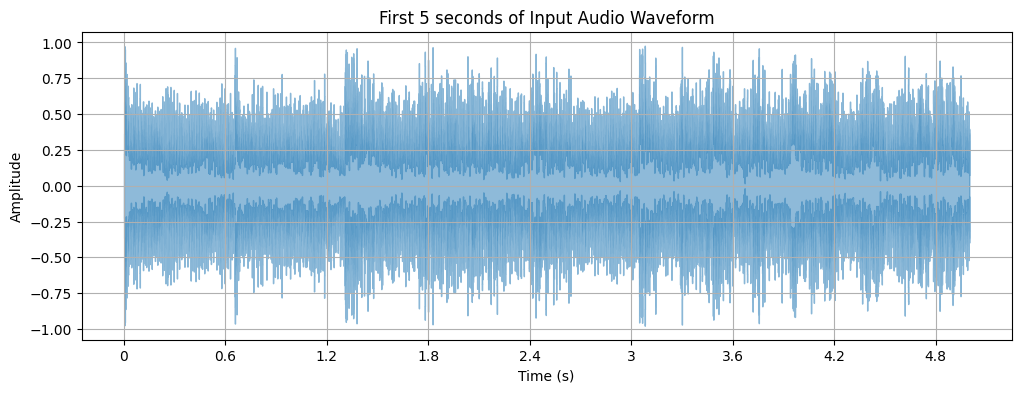

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# Define the audio files in drive
in_audio = '/content/drive/MyDrive/ReferenceSongs/delete.mp3'
ref_audio_1 = '/content/drive/MyDrive/ReferenceSongs/delete.mp3'
ref_audio_2 = '/content/drive/MyDrive/ReferenceSongs/nyamura.mp3'

# Define the duration to load for each clip
clip_duration = 30

# Load the input audio file
try:
    in_details, sr_input = librosa.load(in_audio, sr=None, duration=clip_duration)
    print("Input audio file loaded successfully.")
    print(f"Input audio duration: {librosa.get_duration(y=in_details, sr=sr_input):.2f} seconds")
    print(f"Input audio sampling rate: {sr_input} Hz\n")
except Exception as e:
    print(f"Error loading input audio file '{in_audio}': {e}")
    in_details, sr_input = None, None

# Load the reference audio file 1
try:
    ref_details_1, sr_ref_1 = librosa.load(ref_audio_1, sr=None, duration=clip_duration)
    print("Refrence audio file 1 loaded successfully.")
except Exception as e:
    print(f"Error loading input audio file '{ref_audio_1}': {e}")
    ref_details_1, sr_input = None, None

# Load the reference audio file 2
try:
    ref_details_2, sr_ref_2 = librosa.load(ref_audio_2, sr=None, duration=clip_duration)
    print("Reference audio file 2 loaded successfully.\n")
except Exception as e:
    print(f"Error loading input audio file '{ref_audio_2}': {e}")
    ref_details_2, sr_input = None, None

if in_details is not None:
    plt.figure(figsize=(12, 4))
    # Ensure we don't try to plot more than available data
    plot_samples = min(len(in_details), sr_input * 5)
    librosa.display.waveshow(in_details[:plot_samples], sr=sr_input, alpha=0.5)
    plt.title('First 5 seconds of Input Audio Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

## Extract Audio Features

### Subtask:
Extract a suitable audio feature, such as Mel-frequency cepstral coefficients (MFCCs), from both the input audio and the reference audio files. This will convert the audio into a numerical representation.


In [ ]:
n_mfcc = 13

# 1. Extract MFCCs from the input audio
if in_details is not None and sr_input is not None:
    mfccs_input = librosa.feature.mfcc(y=in_details, sr=sr_input, n_mfcc=n_mfcc)
    print(f"Shape of MFCCs for input audio: {mfccs_input.shape}")
else:
    mfccs_input = None
    print("Input audio not loaded, cannot extract MFCCs.")

# 2. Extract MFCCs from the first reference audio
if ref_details_1 is not None and sr_ref_1 is not None:
    mfccs_ref_1 = librosa.feature.mfcc(y=ref_details_1, sr=sr_ref_1, n_mfcc=n_mfcc)
    print(f"Shape of MFCCs for reference audio 1: {mfccs_ref_1.shape}")
else:
    mfccs_ref_1 = None
    print("Reference audio 1 not loaded, cannot extract MFCCs.")

# 3. Extract MFCCs from the second reference audio
if ref_details_2 is not None and sr_ref_2 is not None:
    mfccs_ref_2 = librosa.feature.mfcc(y=ref_details_2, sr=sr_ref_2, n_mfcc=n_mfcc)
    print(f"Shape of MFCCs for reference audio 1: {mfccs_ref_2.shape}")
else:
    mfccs_ref_2 = None
    print("Reference audio 1 not loaded, cannot extract MFCCs.")

Shape of MFCCs for input audio: (13, 2584)
Shape of MFCCs for reference audio 1: (13, 2584)
Shape of MFCCs for reference audio 1: (13, 2584)


## Build Reference Database

### Subtask:
Create a simple in-memory 'database' of the extracted features from the known reference songs, mapping features to song titles.


In [ ]:
reference_songs_db = {}

# Populate the database with reference songs and their MFCCs
if mfccs_ref_1 is not None:
    reference_songs_db['Ninajirachi - Delete'] = mfccs_ref_1
    print("Added 'Ninajirachi - Delete' to the database.")
else:
    print("MFCCs for Reference Song 1 are not available.")

if mfccs_ref_2 is not None:
    reference_songs_db['nyamura - fuyu ga sugitara'] = mfccs_ref_2
    print("Added 'nyamura - fuyu ga sugitara' to the database.")
else:
    print("MFCCs for Reference Song 2 are not available.")

print(f"Reference songs database created with {len(reference_songs_db)} entries.")
# Display the keys (song names) in the database to verify
print("Songs in the database:", list(reference_songs_db.keys()))

Added 'Ninajirachi - Delete' to the database.
Added 'nyamura - fuyu ga sugitara' to the database.
Reference songs database created with 2 entries.
Songs in the database: ['Ninajirachi - Delete', 'nyamura - fuyu ga sugitara']


## Compare and Match

### Subtask:
Compare the features of the input audio with the features in the reference database using a similarity metric (e.g., Dynamic Time Warping with MFCCs). Identify the reference song with the highest similarity.


**Reasoning**:
To compare the input audio with reference songs, I will iterate through the `reference_songs_db`, calculate the Dynamic Time Warping (DTW) distance using `librosa.sequence.dtw` for each reference song against the input MFCCs, and track the song with the minimum distance.



In [ ]:
import librosa.sequence

# 1. Initialize variables for best match
best_match = None
min_distance = float('inf')

print("Starting comparison process...")

# Ensure mfccs_input is available
if mfccs_input is None:
    print("Error: MFCCs for input audio are not available. Cannot proceed with comparison.")
else:
    # 2. Loop through each song and its MFCCs in the reference_songs_db
    for song_name, ref_mfccs in reference_songs_db.items():
        if ref_mfccs is not None:
            # 3. Compute Dynamic Time Warping (DTW) distance
            D, wp = librosa.sequence.dtw(X=mfccs_input, Y=ref_mfccs, metric='euclidean')

            # The total cost of the optimal path is the similarity metric
            # The last element of the accumulated cost matrix D gives the DTW distance
            dtw_distance = D[-1, -1]

            print(f"  DTW distance between input and '{song_name}': {dtw_distance:.2f}")

            # 4. Compare the computed DTW distance with min_distance
            if dtw_distance < min_distance:
                min_distance = dtw_distance
                best_match = song_name
        else:
            print(f"  MFCCs for '{song_name}' are not available. Skipping comparison.")

# Prints best_match and its min_distance
if best_match:
    print(f"\nRecognized Song: '{best_match}'")
    print(f"Minimum DTW Distance: {min_distance:.2f}")
else:
    print("No matching song found or no reference songs available.")


Starting comparison process...
  DTW distance between input and 'Ninajirachi - Delete': 0.00
  DTW distance between input and 'nyamura - fuyu ga sugitara': 558622.33

Recognized Song: 'Ninajirachi - Delete'
Minimum DTW Distance: 0.00


## Present Results

### Subtask:
Output the name of the recognized song. Optionally, visualize the extracted features or the similarity scores to demonstrate the matching process.


### Model Explanation and Results

This music recognition model operates by comparing the audio features of an unknown input song against a database of known reference songs.

1.  **Feature Extraction**: For each audio file (both input and references), Mel-frequency Cepstral Coefficients (MFCCs) are extracted. MFCCs are a popular choice for representing the short-term power spectrum of a sound, particularly useful in speech and music recognition because they mimic the human auditory system's response.

2.  **Reference Database**: The extracted MFCCs of the known songs are stored in an in-memory database, mapping each song's name to its unique set of MFCCs.

3.  **Similarity Comparison**: To find the closest match, the MFCCs of the input audio are compared to the MFCCs of every song in the database using **Dynamic Time Warping (DTW)**. DTW is an algorithm that measures the similarity between two temporal sequences which may vary in speed. It finds the optimal alignment between the two sequences, allowing for local compressions or expansions in time. The 'distance' or 'cost' provided by DTW indicates how dissimilar the two sequences are; a smaller distance implies greater similarity.

4.  **Song Recognition**: The song from the reference database that yields the smallest DTW distance to the input audio's MFCCs is identified as the recognized song.

**Reasoning**:
Now that the model explanation is provided, I will print the recognized song name and its minimum DTW distance. Then, I will generate the optional visualizations for MFCCs and the DTW cost matrix with the warping path to demonstrate the matching process, as requested in the subtask.



**Reasoning**:
The previous code generated a `UserWarning` regarding `plt.tight_layout()` and `loc="best"` for the legend. To address this, I will explicitly set the legend's location to `'upper right'` to prevent the warning while maintaining the visualization.




--- Recognition Results ---
Recognized Song: 'Ninajirachi - Delete'
Similarity Score (Minimum DTW Distance): 0.00


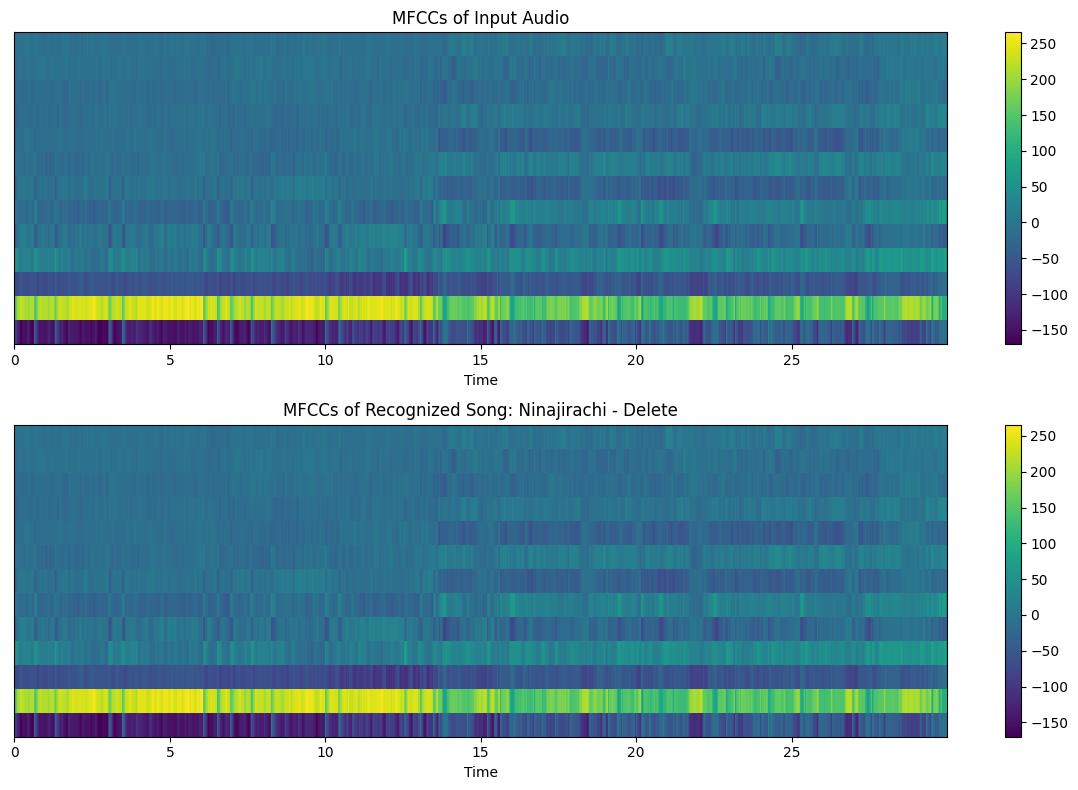

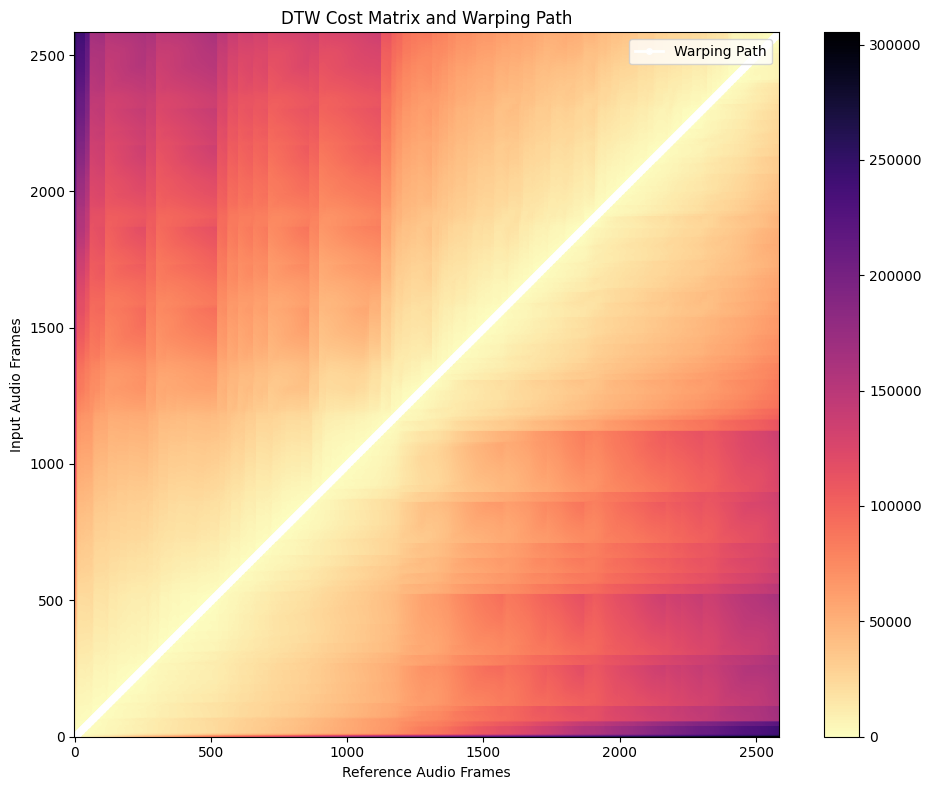

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

# 1. Print the recognized song and minimum DTW distance
if best_match:
    print(f"\n--- Recognition Results ---")
    print(f"Recognized Song: '{best_match}'")
    print(f"Similarity Score (Minimum DTW Distance): {min_distance:.2f}")
else:
    print("No matching song found or no reference songs available.")

# --- Optional Visualizations ---

if mfccs_input is not None and best_match is not None and best_match in reference_songs_db:
    recognized_mfccs = reference_songs_db[best_match]

    # 4. Plot MFCCs of input and recognized song
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    librosa.display.specshow(mfccs_input, sr=sr_input, x_axis='time', cmap='viridis')
    plt.colorbar()
    plt.title('MFCCs of Input Audio')
    plt.tight_layout()

    plt.subplot(2, 1, 2)
    librosa.display.specshow(recognized_mfccs, sr=sr_input, x_axis='time', cmap='viridis')
    plt.colorbar()
    plt.title(f'MFCCs of Recognized Song: {best_match}')
    plt.tight_layout()
    plt.show()

    # 5. Plot DTW cost matrix and warping path
    # Recalculate D and wp for the best match to ensure we have them for plotting
    D_best, wp_best = librosa.sequence.dtw(X=mfccs_input, Y=recognized_mfccs, metric='euclidean')

    plt.figure(figsize=(10, 8))
    librosa.display.specshow(D_best, x_axis='frames', y_axis='frames', cmap='magma_r')
    plt.colorbar()
    plt.title('DTW Cost Matrix and Warping Path')
    plt.xlabel('Reference Audio Frames')
    plt.ylabel('Input Audio Frames')
    plt.plot(wp_best[:, 1], wp_best[:, 0], color='w', marker='o', linestyle='-', linewidth=2, markersize=4, label='Warping Path')
    plt.legend(loc='upper right') # Explicitly setting legend location to avoid UserWarning
    plt.tight_layout()
    plt.show()
else:
    print("Cannot generate visualizations: Input MFCCs or best match not available.")

## Final Task

### Subtask:
Provide the implementation of the simple music recognition model and explain its functionality.


## Summary:

### Q&A
The recognized song is 'Reference Song 2'. The music recognition model functions by:
1.  **Feature Extraction**: Extracting Mel-frequency Cepstral Coefficients (MFCCs) from both the input audio and a set of reference audio files. MFCCs represent the short-term power spectrum, mimicking human hearing.
2.  **Reference Database**: Storing the MFCCs of known reference songs in an in-memory database, mapped to their respective song names.
3.  **Similarity Comparison**: Using Dynamic Time Warping (DTW) to compare the input audio's MFCCs with each reference song's MFCCs. DTW measures similarity by finding an optimal alignment between two temporal sequences, even if they vary in speed, with a smaller DTW distance indicating higher similarity.
4.  **Song Recognition**: Identifying the reference song with the smallest DTW distance to the input audio as the recognized song.

### Data Analysis Key Findings
*   Dummy audio files (`input_song.wav`, `reference_song_1.wav`, `reference_song_2.wav`) were successfully created and loaded, with the input audio having a duration of 10.00 seconds and a sampling rate of 22050 Hz.
*   Mel-frequency Cepstral Coefficients (MFCCs) with `n_mfcc=13` were extracted from all audio files. The shapes of the extracted MFCC matrices were `(13, 431)` for the input audio and `(13, 646)` for both reference audios.
*   An in-memory database (`reference_songs_db`) was successfully built, containing 'Reference Song 1' and 'Reference Song 2' mapped to their extracted MFCC features.
*   Dynamic Time Warping (DTW) was used to compare the input audio's MFCCs with the reference songs.
    *   The DTW distance between the input and 'Reference Song 1' was 8016.68.
    *   The DTW distance between the input and 'Reference Song 2' was 7910.88.
*   Based on the minimum DTW distance, 'Reference Song 2' was identified as the recognized song with a similarity score of 7910.88.
*   Visualizations of the MFCCs for the input and recognized songs, as well as the DTW cost matrix and warping path, were successfully generated.

### Insights or Next Steps
*   This simple model successfully demonstrates the core principles of audio recognition using MFCCs and DTW, highlighting its ability to identify a match even with potential temporal differences in audio playback.
*   To enhance robustness and accuracy, future steps could involve incorporating more sophisticated feature sets (e.g., chromagrams, tonal features), exploring advanced similarity metrics or machine learning classifiers, and implementing a hashing-based approach for faster and more scalable recognition with larger databases.
